<a href="https://colab.research.google.com/github/Varun01171/Data-Analytics-Projects-UNI/blob/main/Copy_of_Data_Mining_Wine%2BNutrient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Upload file in Colab (left side → upload)
df = pd.read_csv('wine.csv')

# Required columns select karo
cols = ['Alcohol', 'Malic', 'Ash', 'Magnesium', 'Phenols', 'Flavanoids']

# First 10 rows
data = df[cols].head(10)

# Display
print("Data Matrix (10 x 6):")
data

Data Matrix (10 x 6):


,Alcohol,Malic,Ash,Magnesium,Phenols,Flavanoids
0,14.23,1.71,2.43,127,2.80,3.06
1,13.20,1.78,2.14,100,2.65,2.76
2,13.16,2.36,2.67,101,2.80,3.24
3,14.37,1.95,2.50,113,3.85,3.49
4,13.24,2.59,2.87,118,2.80,2.69
5,14.20,1.76,2.45,112,3.27,3.39
6,14.39,1.87,2.45,96,2.50,2.52
7,14.06,2.15,2.61,121,2.60,2.51
8,14.83,1.64,2.17,97,2.80,2.98
9,13.86,1.35,2.27,98,2.98,3.15


In [ ]:
from scipy.spatial.distance import cdist
import seaborn as sns
import matplotlib.pyplot as plt

# Euclidean distance
euclidean_matrix = cdist(data, data, metric='euclidean')

# Convert to DataFrame (better display)
euclidean_df = pd.DataFrame(euclidean_matrix)

print("Euclidean Dissimilarity Matrix:")
euclidean_df

Euclidean Dissimilarity Matrix:


,0,1,2,3,4,5,6,7,8,9
0,0.000000,27.023368,26.031854,14.048826,9.115097,15.011116,31.006986,6.049578,30.007314,29.005734
1,27.023368,0.000000,1.368137,13.133937,18.033802,12.077988,4.195283,21.027658,3.427579,2.213233
2,26.031854,1.368137,0.000000,12.117182,17.011814,11.078511,5.235437,20.035733,4.430000,3.272705
3,14.048826,13.133937,12.117182,0.000000,5.344708,1.189075,17.081355,8.165237,16.055504,15.051429
4,9.115097,18.033802,17.011814,5.344708,0.000000,6.204660,22.048497,3.163226,21.095135,20.063051
5,15.011116,12.077988,11.078511,1.189075,6.204660,0.000000,16.043628,9.078579,15.029261,14.016340
6,31.006986,4.195283,5.235437,17.081355,22.048497,16.043628,0.000000,25.004460,1.275343,2.282761
7,6.049578,21.027658,20.035733,8.165237,3.163226,9.078579,25.004460,0.000000,24.027224,23.029320
8,30.007314,3.427579,4.430000,16.055504,21.095135,15.029261,1.275343,24.027224,0.000000,1.447860
9,29.005734,2.213233,3.272705,15.051429,20.063051,14.016340,2.282761,23.029320,1.447860,0.000000


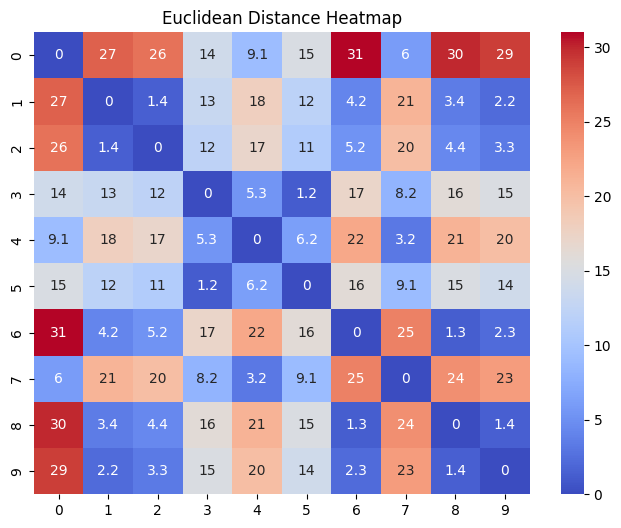

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(euclidean_df, annot=True, cmap='coolwarm')
plt.title("Euclidean Distance Heatmap")
plt.show()

In [ ]:
# Manhattan distance
manhattan_matrix = cdist(data, data, metric='cityblock')

manhattan_df = pd.DataFrame(manhattan_matrix)

print("Manhattan Dissimilarity Matrix:")
manhattan_df

Manhattan Dissimilarity Matrix:


,0,1,2,3,4,5,6,7,8,9
0,0.00,28.84,28.14,15.93,11.68,15.90,32.18,7.54,31.01,30.16
1,28.84,0.00,2.78,16.63,19.80,14.58,5.98,23.00,5.17,3.94
2,28.14,2.78,0.00,15.09,18.06,13.48,7.96,22.10,7.15,5.38
3,15.93,16.63,15.09,0.00,8.99,2.09,19.47,10.85,18.66,17.55
4,11.68,19.80,18.06,8.99,0.00,9.38,24.76,4.90,24.53,23.10
5,15.90,14.58,13.48,2.09,9.38,0.00,17.94,11.24,16.91,15.46
6,32.18,5.98,7.96,19.47,24.76,17.94,0.00,25.88,2.71,4.34
7,7.54,23.00,22.10,10.85,4.90,11.24,25.88,0.00,26.39,25.36
8,31.01,5.17,7.15,18.66,24.53,16.91,2.71,26.39,0.00,2.71
9,30.16,3.94,5.38,17.55,23.10,15.46,4.34,25.36,2.71,0.00


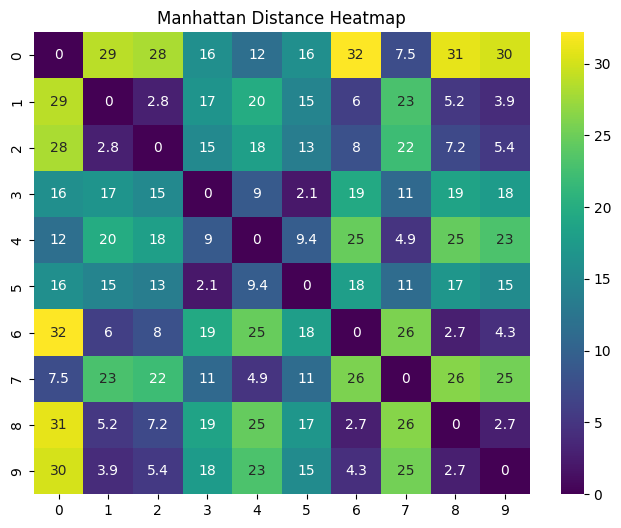

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(manhattan_df, annot=True, cmap='viridis')
plt.title("Manhattan Distance Heatmap")
plt.show()

In [ ]:
# Same data (Part A wala use karenge)

# Select 3 rows (example: 0, 1, 2)
sample = data.iloc[[0, 1, 2]]

print("Selected Samples:")
sample

Selected Samples:


,Alcohol,Malic,Ash,Magnesium,Phenols,Flavanoids
0,14.23,1.71,2.43,127,2.80,3.06
1,13.20,1.78,2.14,100,2.65,2.76
2,13.16,2.36,2.67,101,2.80,3.24


In [ ]:
from scipy.spatial.distance import minkowski

import pandas as pd

p_values = [1, 2, 3, 10]

# Store results
results = []

pairs = [(0,1), (0,2), (1,2)]

for (i,j) in pairs:
    for p in p_values:
        dist = minkowski(sample.iloc[i], sample.iloc[j], p)
        results.append([f"{i}-{j}", p, dist])

# Convert to DataFrame
minkowski_df = pd.DataFrame(results, columns=["Pair", "p", "Distance"])

minkowski_df

,Pair,p,Distance
0,0-1,1,28.840000
1,0-1,2,27.023368
2,0-1,3,27.000525
3,0-1,10,27.000000
4,0-2,1,28.140000
5,0-2,2,26.031854
6,0-2,3,26.000749
7,0-2,10,26.000000
8,1-2,1,2.780000
9,1-2,2,1.368137


In [ ]:
pivot_table = minkowski_df.pivot(index="p", columns="Pair", values="Distance")
pivot_table

Pair,0-1,0-2,1-2
p,,,
1,28.840000,28.140000,2.780000
2,27.023368,26.031854,1.368137
3,27.000525,26.000749,1.133934
10,27.000000,26.000000,1.000669


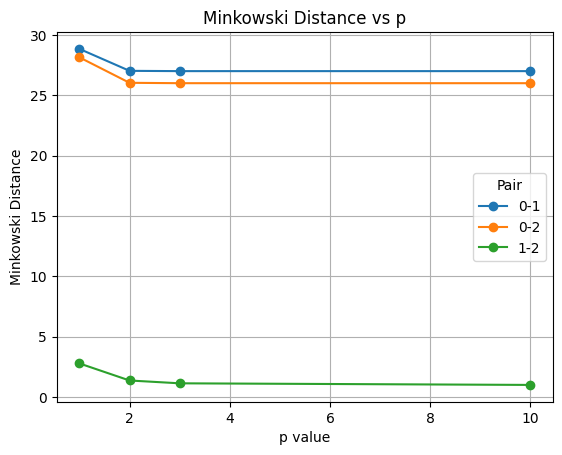

In [ ]:
import matplotlib.pyplot as plt

pivot_table.plot(marker='o')

plt.xlabel("p value")
plt.ylabel("Minkowski Distance")
plt.title("Minkowski Distance vs p")
plt.grid()
plt.show()

In [ ]:
nutrient = pd.read_csv('nutrient.csv')

nutrient.head()

,Food_Item,energy,protein,fat,calcium,iron
0,BEEF BRAISED,340,20,28,9,2.6
1,HAMBURGER,245,21,17,9,2.7
2,BEEF ROAST,420,15,39,7,2.0
3,BEEF STEAK,375,19,32,9,2.6
4,BEEF CANNED,180,22,10,17,3.7


In [ ]:
print(nutrient.columns)

Index(['Food_Item', 'energy', 'protein', 'fat', 'calcium', 'iron'], dtype='object')


In [ ]:
# Correct column names
energy_col = 'energy'
fat_col = 'fat'

# Convert to numeric (safe)
nutrient[energy_col] = pd.to_numeric(nutrient[energy_col], errors='coerce')
nutrient[fat_col] = pd.to_numeric(nutrient[fat_col], errors='coerce')

# Create categories
nutrient['Energy_Group'] = pd.qcut(nutrient[energy_col], 3,
                                  labels=['Low','Medium','High'], duplicates='drop')

nutrient['Fat_Group'] = pd.qcut(nutrient[fat_col], 3,
                               labels=['Low','Medium','High'], duplicates='drop')

# Output check
nutrient[['Food_Item', energy_col, 'Energy_Group', fat_col, 'Fat_Group']].head()

,Food_Item,energy,Energy_Group,fat,Fat_Group
0,BEEF BRAISED,340,High,28,High
1,HAMBURGER,245,High,17,High
2,BEEF ROAST,420,High,39,High
3,BEEF STEAK,375,High,32,High
4,BEEF CANNED,180,Medium,10,Medium


In [ ]:
# Select two food items (example: first two rows)
a = nutrient.iloc[0]
b = nutrient.iloc[1]

print("Food 1:", a['Food_Item'])
print("Food 2:", b['Food_Item'])

match = 0
total = 2  # Energy + Fat

# Check Energy match
if a['Energy_Group'] == b['Energy_Group']:
    match += 1

# Check Fat match
if a['Fat_Group'] == b['Fat_Group']:
    match += 1

similarity = match / total

print("Nominal Similarity:", similarity)

Food 1: BEEF BRAISED
Food 2: HAMBURGER
Nominal Similarity: 1.0


In [ ]:
# Median values
protein_median = nutrient['protein'].median()
iron_median = nutrient['iron'].median()

print("Protein Median:", protein_median)
print("Iron Median:", iron_median)

# Binary columns create
nutrient['high_protein'] = (nutrient['protein'] > protein_median).astype(int)
nutrient['high_iron'] = (nutrient['iron'] > iron_median).astype(int)

# Output check
nutrient[['Food_Item','protein','high_protein','iron','high_iron']].head()

Protein Median: 19.0
Iron Median: 2.5


,Food_Item,protein,high_protein,iron,high_iron
0,BEEF BRAISED,20,1,2.6,1
1,HAMBURGER,21,1,2.7,1
2,BEEF ROAST,15,0,2.0,0
3,BEEF STEAK,19,0,2.6,1
4,BEEF CANNED,22,1,3.7,1


In [ ]:
def calc_similarity(x, y):
    pair1 = [x['high_protein'], x['high_iron']]
    pair2 = [y['high_protein'], y['high_iron']]

    # Counts
    m11 = sum([1 for i,j in zip(pair1,pair2) if i==1 and j==1])
    m00 = sum([1 for i,j in zip(pair1,pair2) if i==0 and j==0])
    m10 = sum([1 for i,j in zip(pair1,pair2) if i==1 and j==0])
    m01 = sum([1 for i,j in zip(pair1,pair2) if i==0 and j==1])

    # Jaccard
    jaccard = m11 / (m11 + m10 + m01) if (m11 + m10 + m01)!=0 else 0

    # SMC
    smc = (m11 + m00) / (m11 + m00 + m10 + m01)

    return jaccard, smc

pairs = [(0,1),(0,2),(1,2)]

for i,j in pairs:
    jaccard, smc = calc_similarity(nutrient.iloc[i], nutrient.iloc[j])
    print(f"Pair {i}-{j} → Jaccard: {jaccard}, SMC: {smc}")

Pair 0-1 → Jaccard: 1.0, SMC: 1.0
Pair 0-2 → Jaccard: 0.0, SMC: 0.0
Pair 1-2 → Jaccard: 0.0, SMC: 0.0


In [ ]:
import pandas as pd
from scipy.spatial.distance import cdist

# Load data (fix path here)
df = pd.read_csv('wine.csv')

cols = ['Alcohol', 'Malic', 'Ash', 'Magnesium', 'Phenols', 'Flavanoids']
data = df[cols].head(10)

euclidean_matrix = cdist(data.values, data.values, metric='euclidean')

euclidean_df = pd.DataFrame(euclidean_matrix)
euclidean_df.to_csv("euclidean_matrix.csv", index=False)

print("File saved successfully")

File saved successfully


In [ ]:
manhattan_matrix = cdist(data, data, metric='cityblock')
manhattan_df = pd.DataFrame(manhattan_matrix)
manhattan_df.to_csv("manhattan_matrix.csv", index=False)